# Day 1 — Sprint 2 Planning & Convolutional Neural Networks

## Step 1: Sprint 2 Planning

### Sprint 2 Goal

Develop and improve the project's core model using the architecture that best fits the data type, evaluate different approaches, and achieve better performance than the Week 6 baseline.

### Sprint 2 Backlog

- Review the Sprint 1 baseline and identify one improvement to carry forward.
- Study CNNs and understand convolution, filters, feature maps, stride, and padding.
- Build and train a small CNN on image data.
- Experiment with data augmentation.
- Apply transfer learning using a pre-trained CNN model.
- Study RNNs and LSTMs for sequential data.
- Build and evaluate an LSTM on sequential data.
- Study attention and Transformers.
- Test a pre-trained Transformer using Hugging Face.
- Compare the architectures that are relevant to the project's data type.
- Select and justify the final core architecture.
- Train and tune the selected core model.
- Log experiment settings and evaluation metrics.
- Compare the Sprint 2 model with the Week 6 baseline and Sprint 1 model.
- Prepare training curves and a metric comparison table.
- Complete the Sprint Review and Retrospective.

### Sprint 1 Improvement to Carry Forward

In Sprint 2, experiments will be documented more clearly by recording the model configuration and evaluation metric for each run, making it easier to compare results and identify improvements.

## Step 2: Apply an Edge Detection Filter

### Import Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

### Create a Sample Image

tf.constant to create a image 

data type because tensorflow use float for the calculations

In [2]:
image = tf.constant([
    [0, 0, 0, 255, 255],
    [0, 0, 0, 255, 255],
    [0, 0, 0, 255, 255],
    [0, 0, 0, 255, 255],
    [0, 0, 0, 255, 255]
], dtype=tf.float32)

### Display the Original Image

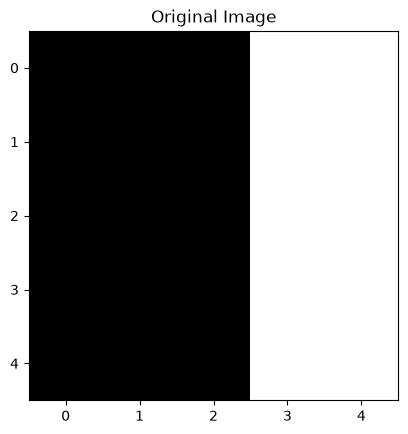

In [6]:
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.show()

### Reshape the Image

TensorFlow expects image data in the following format:

`[Batch, Height, Width, Channels]`

For our sample image:

* `Batch = 1` → one image
* `Height = 5` → image height
* `Width = 5` → image width
* `Channels = 1` → grayscale image

So the required shape is:

`[1, 5, 5, 1]`

General format:

`[number_of_images, height, width, channels]`


In [8]:
image_reshaped=tf.reshape(image,[1,5,5,1])

### Define the Vertical Edge Detection Filter

tf.constant to create a filter 

data type because tensorflow use float for the calculations

In [9]:
filter1 = tf.constant([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=tf.float32)

### Reshape the Filter

TensorFlow expects the convolution filter in the following format:

`[Filter Height, Filter Width, Input Channels, Number of Filters]`

For our filter:

* `Filter Height = 3` → filter height
* `Filter Width = 3` → filter width
* `Input Channels = 1` → the input image is grayscale
* `Number of Filters = 1` → we are using one filter

So the required shape is:

`[3, 3, 1, 1]`

General format:

`[filter_height, filter_width, input_channels, number_of_filters]`


In [10]:
filter_reshaped=tf.reshape(filter1,[3,3,1,1])

### Apply the Convolution

### `tf.nn.conv2d` vs `Conv2D`

* `tf.nn.conv2d` → applies a manually defined filter to an image.
* `Conv2D` → creates learnable filters inside a CNN model.

For Step 2, we use `tf.nn.conv2d` because the filter is defined manually.


In [12]:
feture_map=tf.nn.conv2d(image_reshaped,filter_reshaped,strides=1 ,padding='VALID')

### Feature Map Output Size

$$Output Size = ((N - F) / S) + 1$$

N = 5 

 F = 3  

S = 1  

$$Output Size = ((5 - 3) / 1) + 1 = 3$$

### Visualize the Feature Map

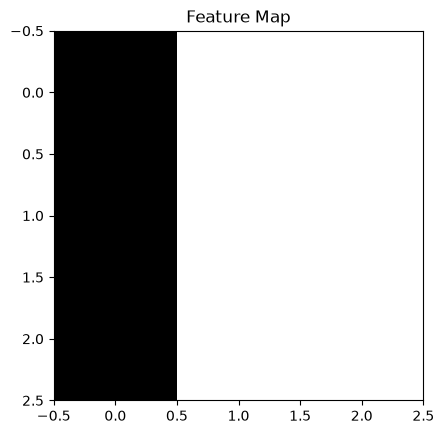

In [14]:
feature_map_2d = tf.squeeze(feture_map)

plt.imshow(feature_map_2d, cmap="gray")
plt.title("Feature Map")
plt.show()

### Convert the Feature Map to 2D

`tf.nn.conv2d` returns the feature map with extra dimensions.

`tf.squeeze()` removes dimensions of size 1 and converts the output into a simple 2D matrix that can be displayed easily.

Example:

`(1, 3, 3, 1) → (3, 3)`


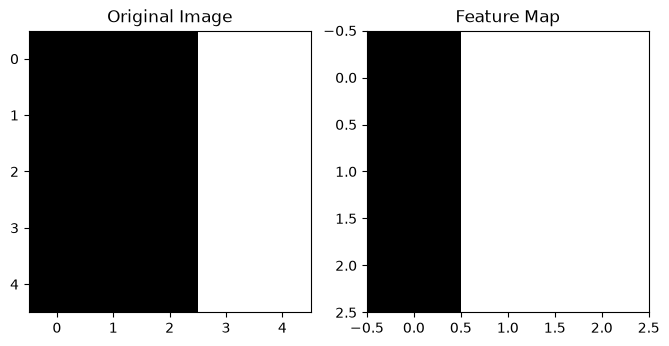

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original Image")
ax[1].imshow(feature_map_2d, cmap="gray")
ax[1].set_title("Feature Map")
plt.show()

### Compare the Original Image and Feature Map

The original image and the feature map are displayed side by side.

- In the original image, black pixels have low values and white pixels have high values.
- After applying the edge-detection filter, areas with stronger edge responses appear brighter.
- White areas in the feature map represent higher values, meaning the filter detected a stronger vertical edge there.
- Darker areas represent lower values, meaning little or no edge was detected.

## Step 3: Why CNNs Use Fewer Weights

### Parameter Sharing

A CNN uses the same small filter across the entire image.

For example, a 3×3 filter has only 9 weights, and these same weights are reused at every image location.

A dense layer uses different weights for many connections, so the total number of parameters becomes much larger.

This is called parameter sharing.

### Simple Example

For a 3×3 grayscale filter:

`3 × 3 = 9 weights`

The same 9 weights are reused across the whole image.

This makes convolution much more efficient than a dense layer.

## Step 4: Choose the Core Model Architecture

### Architecture Decision

The project uses image data, so a Convolutional Neural Network (CNN) is the appropriate core architecture.

CNNs are designed to preserve spatial information in images, detect visual patterns using filters, and learn features such as edges, shapes, textures, and objects.